<a href="https://colab.research.google.com/github/anu-006/Mumbai_House_Price_Predictor/blob/main/Mumbai_House_Price_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Understanding Data

In [37]:
!pip install category_encoders
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.6 MB/s eta 0:00:00


In [38]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from category_encoders import TargetEncoder


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor


In [39]:
data=pd.read_csv('mumbai-house-price-data-cleaned.csv')
data

,title,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude
0,Octave Parijas Horizon,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.244410,73.123253
1,Shakti Siyara Heights,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.257294,73.148872
2,Bhagwati Bhagwati Celeste,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.209026,73.081276
3,Relcon Ridhi Sidhi Sadan Of Ridhi Sidhi Co Ope...,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.097841,72.851158
4,J P Ruchita Bliss,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.420601,72.809319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71933,Shri Ratan Address,38931000,683,57000.000000,Dadar,Mumbai South,Apartment,2,2,0,Furnished,0,1,19.018014,72.832026
71934,Shri Ratan Address,54663000,959,57000.000000,Dadar,Mumbai South,Apartment,3,3,0,Furnished,0,1,19.018014,72.832026
71935,Alpine Primo,15135866,422,35866.981043,Andheri,Western Mumbai,Apartment,1,1,0,Furnished,0,1,19.124240,72.842760
71936,Alpine Primo,25500000,713,35764.375877,Andheri,Western Mumbai,Apartment,2,2,0,Furnished,0,1,19.124240,72.842760


In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71938 entries, 0 to 71937
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           71938 non-null  object 
 1   price           71938 non-null  int64  
 2   area            71938 non-null  int64  
 3   price_per_sqft  71938 non-null  float64
 4   locality        71938 non-null  object 
 5   city            71938 non-null  object 
 6   property_type   71938 non-null  object 
 7   bedroom_num     71938 non-null  int64  
 8   bathroom_num    71938 non-null  int64  
 9   balcony_num     71938 non-null  int64  
 10  furnished       71938 non-null  object 
 11  age             71938 non-null  int64  
 12  total_floors    71938 non-null  int64  
 13  latitude        71938 non-null  float64
 14  longitude       71938 non-null  float64
dtypes: float64(3), int64(7), object(5)
memory usage: 8.2+ MB


In [41]:
data.describe()

,price,area,price_per_sqft,bedroom_num,bathroom_num,balcony_num,age,total_floors,latitude,longitude
count,7.193800e+04,71938.000000,71938.000000,71938.000000,71938.000000,71938.000000,71938.000000,71938.000000,71938.000000,71938.000000
mean,1.951272e+07,943.251369,18489.401813,1.993884,2.082432,0.164336,2.247852,1.004740,19.171970,72.964390
std,3.320767e+07,645.881922,12691.857370,0.914573,0.854540,0.593804,4.230751,0.381272,0.465753,0.406728
min,3.200000e+04,123.000000,25.376685,0.000000,1.000000,0.000000,0.000000,1.000000,12.889899,72.435379
25%,6.524250e+06,595.000000,9230.769231,1.000000,2.000000,0.000000,0.000000,1.000000,19.071314,72.858833
50%,1.200000e+07,775.000000,16080.402010,2.000000,2.000000,0.000000,0.000000,1.000000,19.164281,72.916528
75%,2.150000e+07,1100.000000,23913.043478,3.000000,2.000000,0.000000,3.000000,1.000000,19.229946,73.021536
max,2.147484e+09,24109.000000,290000.000000,15.000000,15.000000,15.000000,57.000000,70.000000,72.868339,91.804413


In [42]:
(data.isnull().sum()*100)

,0
title,0
price,0
area,0
price_per_sqft,0
locality,0
city,0
property_type,0
bedroom_num,0
bathroom_num,0
balcony_num,0


In [43]:
(data.duplicated().mean())*100


np.float64(28.039422836331283)

In [44]:
data.corr(numeric_only=True)

,price,area,price_per_sqft,bedroom_num,bathroom_num,balcony_num,age,total_floors,latitude,longitude
price,1.000000,0.713341,0.655615,0.538222,0.526913,0.067590,0.033598,0.033678,-0.061491,-0.081867
area,0.713341,1.000000,0.252834,0.761244,0.733348,0.234084,0.129794,0.029538,-0.029681,0.001878
price_per_sqft,0.655615,0.252834,1.000000,0.390970,0.368813,-0.095772,-0.069192,0.003489,-0.102111,-0.172617
bedroom_num,0.538222,0.761244,0.390970,1.000000,0.892206,0.172121,0.059063,0.006820,-0.029975,-0.019428
bathroom_num,0.526913,0.733348,0.368813,0.892206,1.000000,0.162028,0.034644,0.011558,-0.035066,-0.040275
balcony_num,0.067590,0.234084,-0.095772,0.172121,0.162028,1.000000,0.128533,0.034075,-0.004887,0.018603
age,0.033598,0.129794,-0.069192,0.059063,0.034644,0.128533,1.000000,0.005468,0.017106,0.025921
total_floors,0.033678,0.029538,0.003489,0.006820,0.011558,0.034075,0.005468,1.000000,0.000444,-0.004218
latitude,-0.061491,-0.029681,-0.102111,-0.029975,-0.035066,-0.004887,0.017106,0.000444,1.000000,0.303687
longitude,-0.081867,0.001878,-0.172617,-0.019428,-0.040275,0.018603,0.025921,-0.004218,0.303687,1.000000


In [45]:
data.cov(numeric_only=True)

,price,area,price_per_sqft,bedroom_num,bathroom_num,balcony_num,age,total_floors,latitude,longitude
price,1.102749e+15,1.529989e+10,2.763202e+11,1.634627e+07,1.495237e+07,1.332790e+06,4.720354e+06,426397.915173,-951048.578531,-1.105731e+06
area,1.529989e+10,4.171635e+05,2.072593e+06,4.496716e+02,4.047584e+02,8.977777e+01,3.546719e+02,7.273924,-8.928599,4.934571e-01
price_per_sqft,2.763202e+11,2.072593e+06,1.610832e+08,4.538241e+03,4.000033e+03,-7.217818e+02,-3.715355e+03,16.885718,-603.608015,-8.910734e+02
bedroom_num,1.634627e+07,4.496716e+02,4.538241e+03,8.364445e-01,6.972944e-01,9.347495e-02,2.285341e-01,0.002378,-0.012768,-7.227048e-03
bathroom_num,1.495237e+07,4.047584e+02,4.000033e+03,6.972944e-01,7.302386e-01,8.221760e-02,1.252518e-01,0.003766,-0.013957,-1.399835e-02
balcony_num,1.332790e+06,8.977777e+01,-7.217818e+02,9.347495e-02,8.221760e-02,3.526033e-01,3.229060e-01,0.007715,-0.001352,4.492824e-03
age,4.720354e+06,3.546719e+02,-3.715355e+03,2.285341e-01,1.252518e-01,3.229060e-01,1.789926e+01,0.008820,0.033707,4.460310e-02
total_floors,4.263979e+05,7.273924e+00,1.688572e+01,2.378271e-03,3.765665e-03,7.714548e-03,8.819972e-03,0.145369,0.000079,-6.541075e-04
latitude,-9.510486e+05,-8.928599e+00,-6.036080e+02,-1.276824e-02,-1.395650e-02,-1.351659e-03,3.370722e-02,0.000079,0.216925,5.752879e-02
longitude,-1.105731e+06,4.934571e-01,-8.910734e+02,-7.227048e-03,-1.399835e-02,4.492824e-03,4.460310e-02,-0.000654,0.057529,1.654274e-01


# Univariate Analysis

In [46]:
data['title'].value_counts()

,count
title,
,11595
Paradise Sai World Empire Phase 1,384
Runwal Bliss,371
Piramal Vaikunth Thane,348
Hiranandani Fortune City,280
...,...
Parshuram Plazakatrap,1
Oberoi Priviera,1
Arkade Pearl,1


In [47]:
data['locality'].value_counts()

,count
locality,
Thane,8211
Mira Road,4872
Kandivali,2933
Kharghar,2843
Andheri,2671
...,...
Police Colony,1
"Nehru Nagar, Kanjurmarg",1
Amboli,1


In [48]:
data['city'].value_counts()

,count
city,
Mumbai,70882
Western Mumbai,489
Central Mumbai,362
Mumbai South,205


In [49]:
data['property_type'].value_counts()

,count
property_type,
Apartment,70858
Independent House,471
Villa,415
Independent Floor,192
Studio Apartment,2


In [50]:
data['furnished'].value_counts()

,count
furnished,
Unfurnished,49917
Semi-Furnished,17056
Furnished,4965


In [51]:
data['total_floors'].value_counts()

,count
total_floors,
1,71875
4,25
3,14
5,12
2,4
6,2
7,2
14,2
70,2


<Axes: xlabel='count', ylabel='city'>

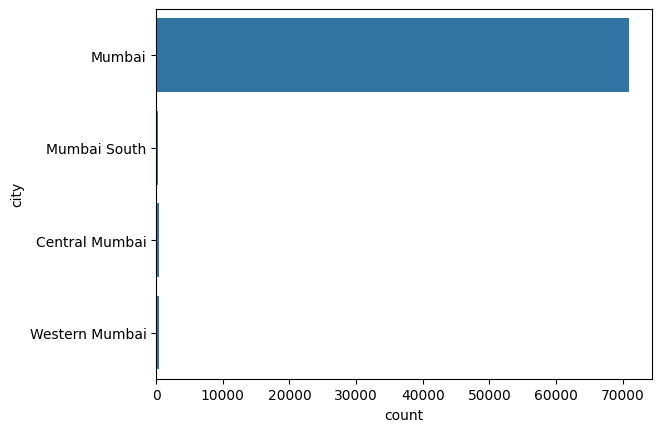

In [52]:
sns.countplot(data['city'])

<Axes: xlabel='count', ylabel='property_type'>

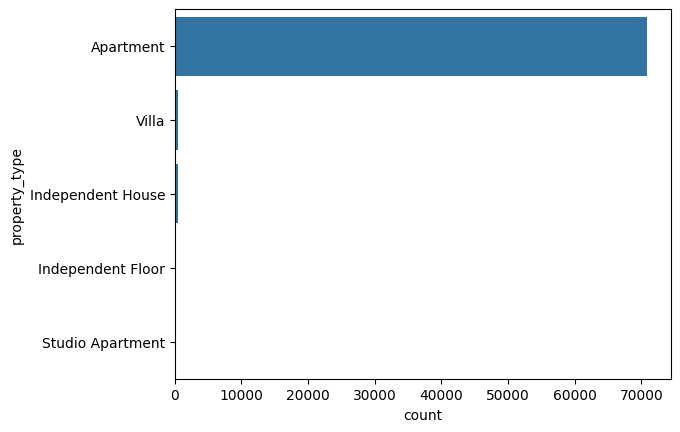

In [53]:
sns.countplot(data['property_type'])

<Axes: xlabel='count', ylabel='furnished'>

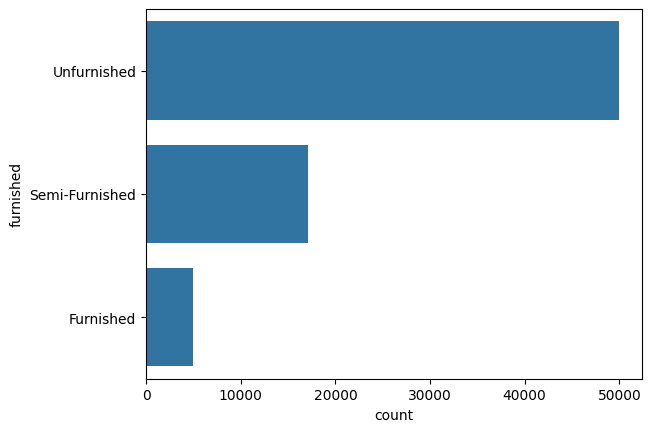

In [54]:
sns.countplot(data['furnished'])

<Axes: xlabel='area', ylabel='Density'>

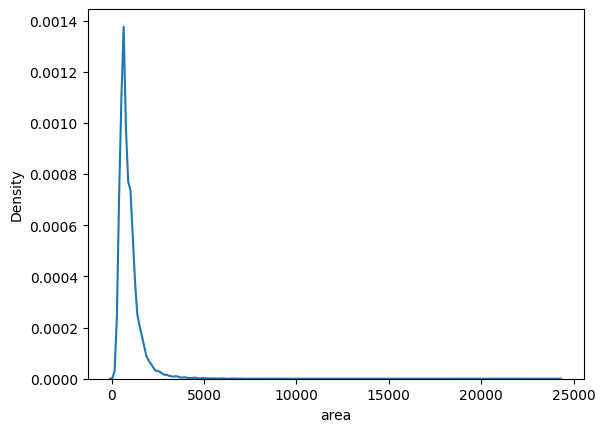

In [55]:
sns.kdeplot(data['area'])

In [56]:
data['area'].skew()

np.float64(6.763863452028727)

<Axes: xlabel='price_per_sqft', ylabel='Density'>

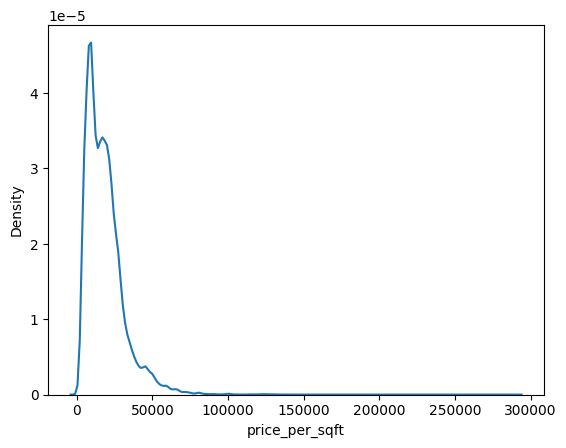

In [57]:
sns.kdeplot(data['price_per_sqft'])

In [58]:
data['price_per_sqft'].skew()

np.float64(2.1303923690220525)

<Axes: xlabel='bedroom_num', ylabel='Density'>

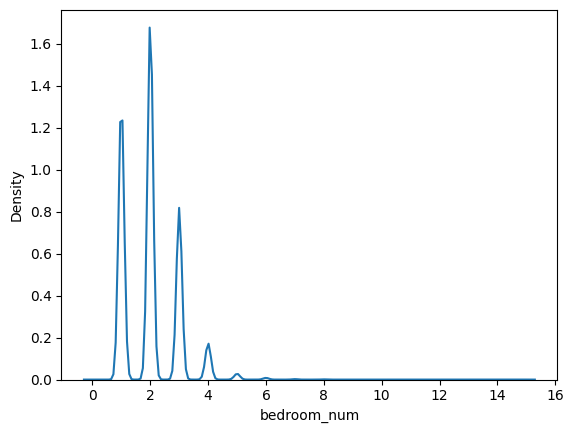

In [59]:
sns.kdeplot(data['bedroom_num'])

In [60]:
data['bedroom_num'].skew()

np.float64(1.172935438216161)

<Axes: xlabel='bathroom_num', ylabel='Density'>

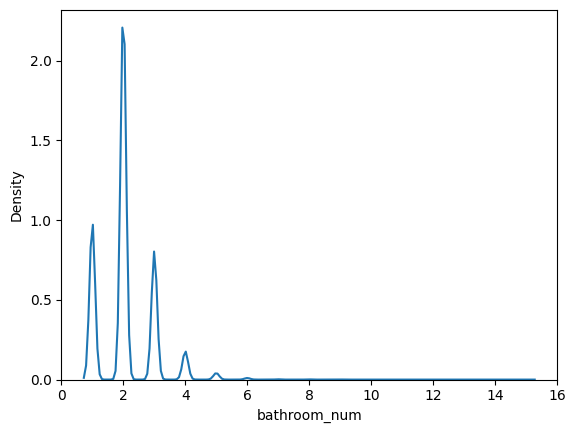

In [61]:
sns.kdeplot(data['bathroom_num'])

In [62]:
data['bathroom_num'].skew()

np.float64(1.321866749648518)

<Axes: xlabel='balcony_num', ylabel='Density'>

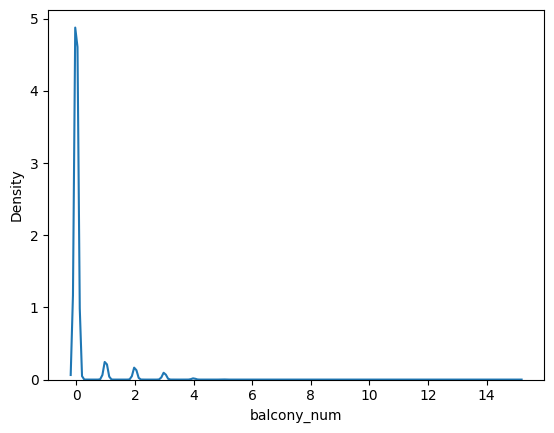

In [63]:
sns.kdeplot(data['balcony_num'])

In [64]:
data['balcony_num'].skew()

np.float64(4.889102973497322)

<Axes: xlabel='age', ylabel='Density'>

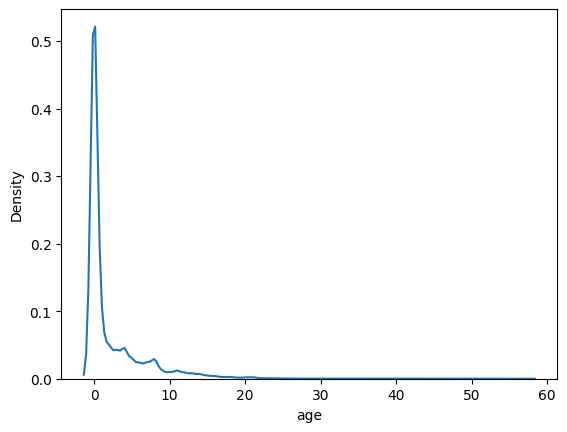

In [65]:
sns.kdeplot(data['age'])

In [66]:
data['age'].skew()

np.float64(2.9560987925550615)

<Axes: xlabel='total_floors', ylabel='Density'>

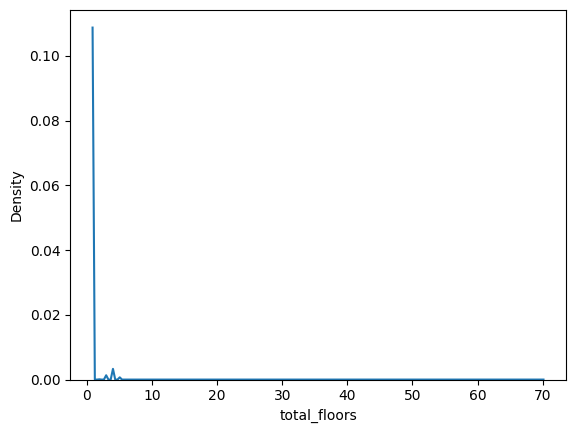

In [67]:
sns.kdeplot(data['total_floors'])

In [68]:
data['total_floors'].skew()

np.float64(166.41689214213264)

<Axes: xlabel='latitude', ylabel='Density'>

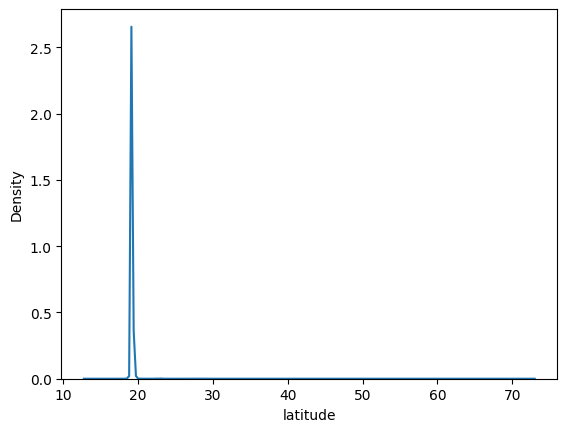

In [69]:
sns.kdeplot(data['latitude'])

In [70]:
data['latitude'].skew()

np.float64(70.50787146849453)

<Axes: xlabel='longitude', ylabel='Density'>

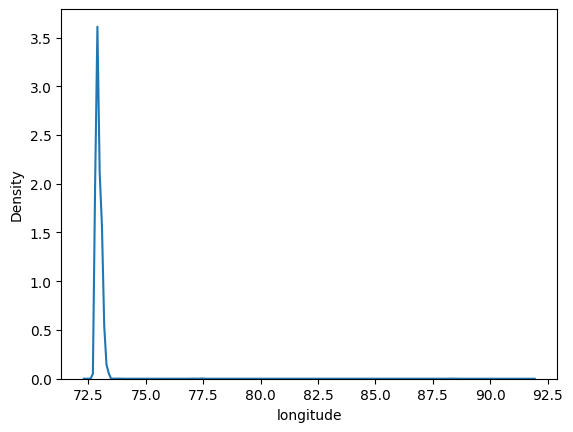

In [71]:
sns.kdeplot(data['longitude'])

In [72]:
data['longitude'].skew()

np.float64(31.38380511190737)

In [73]:
data.drop(columns=['latitude','longitude'])

,title,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors
0,Octave Parijas Horizon,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1
1,Shakti Siyara Heights,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1
2,Bhagwati Bhagwati Celeste,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1
3,Relcon Ridhi Sidhi Sadan Of Ridhi Sidhi Co Ope...,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1
4,J P Ruchita Bliss,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71933,Shri Ratan Address,38931000,683,57000.000000,Dadar,Mumbai South,Apartment,2,2,0,Furnished,0,1
71934,Shri Ratan Address,54663000,959,57000.000000,Dadar,Mumbai South,Apartment,3,3,0,Furnished,0,1
71935,Alpine Primo,15135866,422,35866.981043,Andheri,Western Mumbai,Apartment,1,1,0,Furnished,0,1
71936,Alpine Primo,25500000,713,35764.375877,Andheri,Western Mumbai,Apartment,2,2,0,Furnished,0,1


# Bivariate Analysis

In [74]:
data=data[data['title'].str.strip()!='']
data=data[data['locality'].str.strip()!='']

In [75]:
top10=data['title'].value_counts().nlargest(10).index
top10


Index(['Paradise Sai World Empire Phase 1', 'Runwal Bliss',
       'Piramal Vaikunth Thane', 'Hiranandani Fortune City',
       'Paradise Sai World City', 'JP North', 'Kalpataru Parkcity',
       'Swaminarayan City', 'Lodha Sterling', 'Hiranandani Meadows'],
      dtype='object', name='title')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Lodha Sterling'),
  Text(1, 0, 'JP North'),
  Text(2, 0, 'Runwal Bliss'),
  Text(3, 0, 'Hiranandani Meadows'),
  Text(4, 0, 'Paradise Sai World City'),
  Text(5, 0, 'Piramal Vaikunth Thane'),
  Text(6, 0, 'Swaminarayan City'),
  Text(7, 0, 'Kalpataru Parkcity'),
  Text(8, 0, 'Hiranandani Fortune City'),
  Text(9, 0, 'Paradise Sai World Empire Phase 1')])

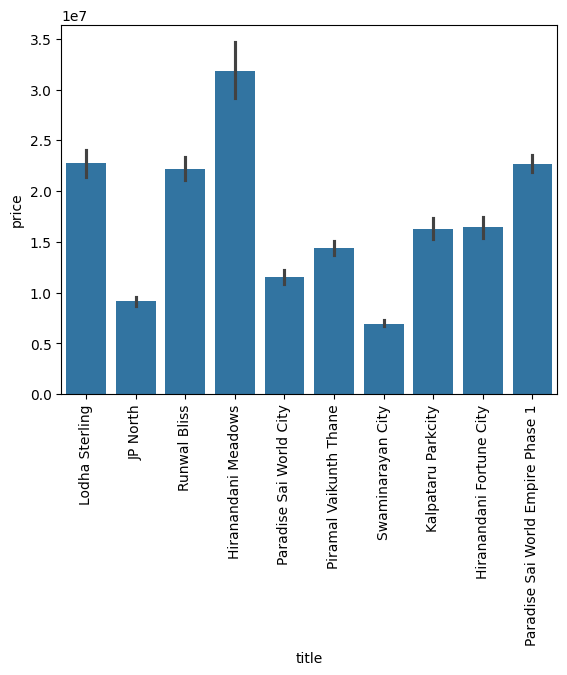

In [76]:
from matplotlib import axis

new_data=data[data['title'].isin(top10)]

sns.barplot(x='title',y='price',data=new_data)
plt.xticks(rotation=90)

In [77]:
top10_locality=data['locality'].value_counts().nlargest(10).index
top10_locality

Index(['Thane', 'Mira Road', 'Kandivali', 'Kharghar', 'Andheri', 'Dombivali',
       'Panvel', 'Chembur', 'Borivali', 'Kalyan'],
      dtype='object', name='locality')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Kalyan'),
  Text(1, 0, 'Dombivali'),
  Text(2, 0, 'Chembur'),
  Text(3, 0, 'Andheri'),
  Text(4, 0, 'Borivali'),
  Text(5, 0, 'Kandivali'),
  Text(6, 0, 'Mira Road'),
  Text(7, 0, 'Kharghar'),
  Text(8, 0, 'Panvel'),
  Text(9, 0, 'Thane')])

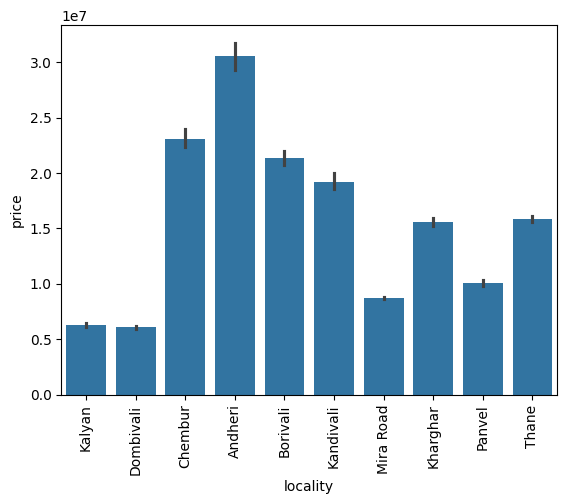

In [78]:
new_data2=data[data['locality'].isin(top10_locality)]

sns.barplot(x='locality',y='price',data=new_data2)
plt.xticks(rotation=90)

([0, 1, 2, 3],
 [Text(0, 0, 'Mumbai'),
  Text(1, 0, 'Mumbai South'),
  Text(2, 0, 'Central Mumbai'),
  Text(3, 0, 'Western Mumbai')])

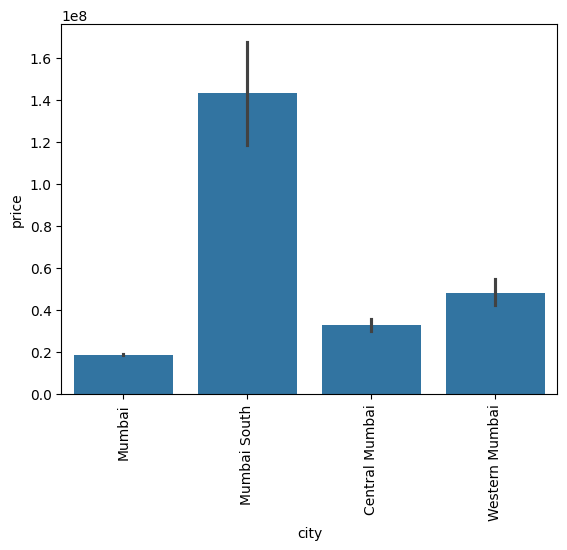

In [79]:
sns.barplot(x=data['city'],y=data['price'])
plt.xticks(rotation=90)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Apartment'),
  Text(1, 0, 'Villa'),
  Text(2, 0, 'Independent Floor'),
  Text(3, 0, 'Independent House'),
  Text(4, 0, 'Studio Apartment')])

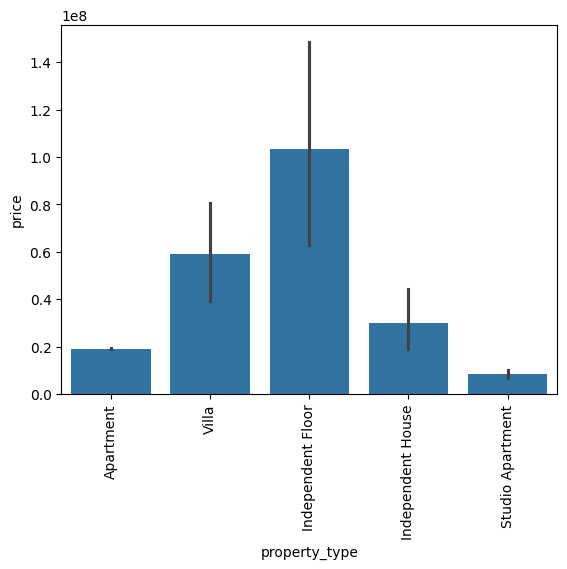

In [80]:
sns.barplot(x=data['property_type'],y=data['price'])
plt.xticks(rotation=90)

([0, 1, 2],
 [Text(0, 0, 'Unfurnished'),
  Text(1, 0, 'Semi-Furnished'),
  Text(2, 0, 'Furnished')])

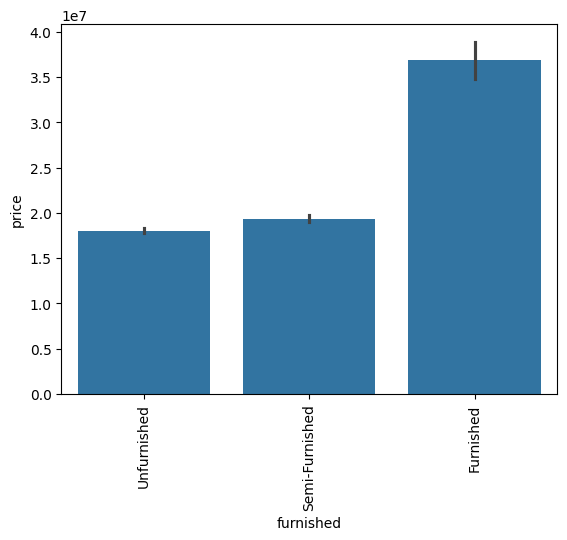

In [81]:
sns.barplot(x=data['furnished'],y=data['price'])
plt.xticks(rotation=90)

Text(0.5, 1.0, 'Square_Foot_Area v/s Price')

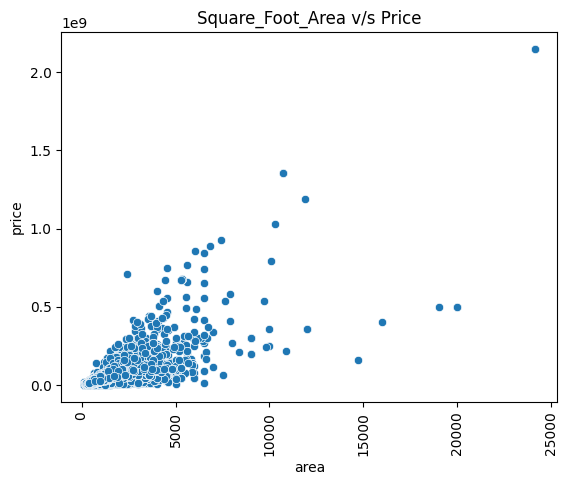

In [82]:
sns.scatterplot(x=data['area'],y=data['price'])
plt.xticks(rotation=90)
plt.title('Square_Foot_Area v/s Price')

Text(0.5, 1.0, 'Price_per_sqft v/s Price')

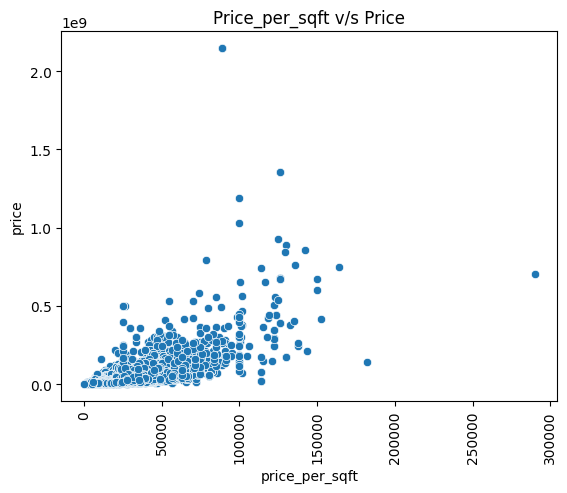

In [83]:
sns.scatterplot(x=data['price_per_sqft'],y=data['price'])
plt.xticks(rotation=90)
plt.title('Price_per_sqft v/s Price')

Text(0.5, 1.0, 'Bedroom_no v/s Price')

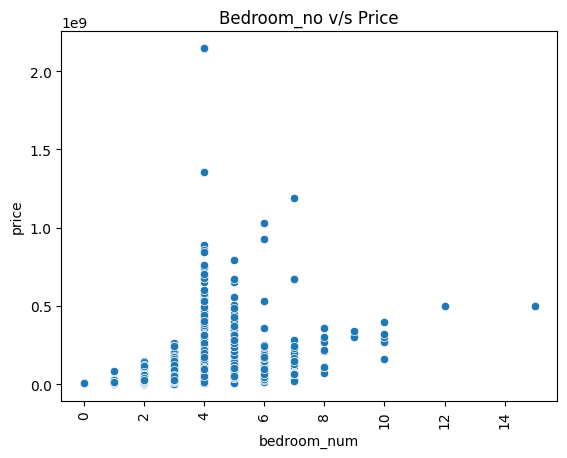

In [84]:
sns.scatterplot(x=data['bedroom_num'],y=data['price'])
plt.xticks(rotation=90)
plt.title('Bedroom_no v/s Price')

Text(0.5, 1.0, 'Bathroom_no v/s Price')

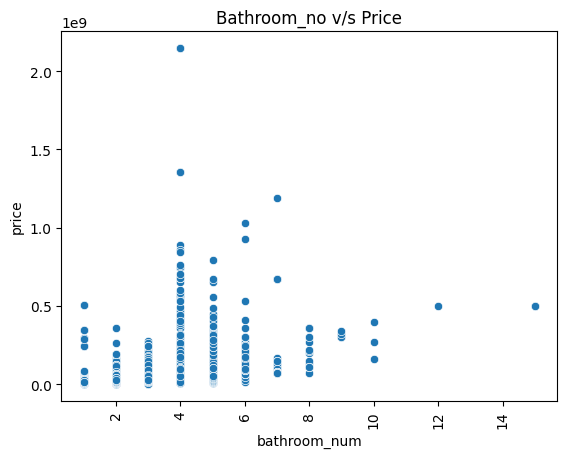

In [85]:
sns.scatterplot(x=data['bathroom_num'],y=data['price'])
plt.xticks(rotation=90)
plt.title('Bathroom_no v/s Price')

Text(0.5, 1.0, 'Balcony_no v/s Price')

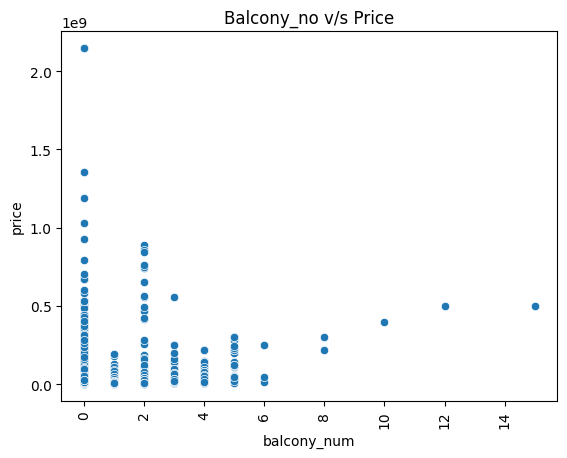

In [86]:
sns.scatterplot(x=data['balcony_num'],y=data['price'])
plt.xticks(rotation=90)
plt.title('Balcony_no v/s Price')

Text(0.5, 1.0, 'Age v/s Price')

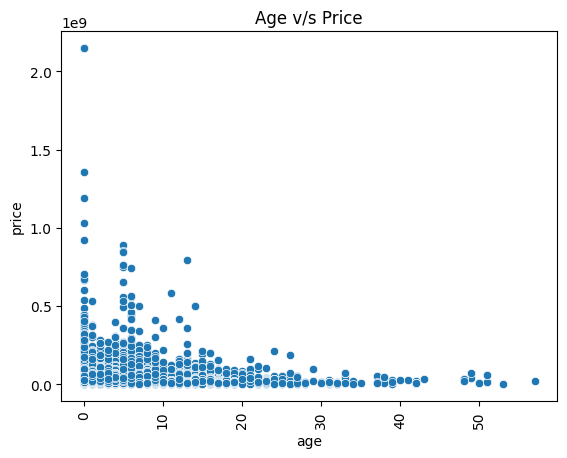

In [87]:
sns.scatterplot(x=data['age'],y=data['price'])
plt.xticks(rotation=90)
plt.title('Age v/s Price')

Text(0.5, 1.0, 'Total_floors v/s Price')

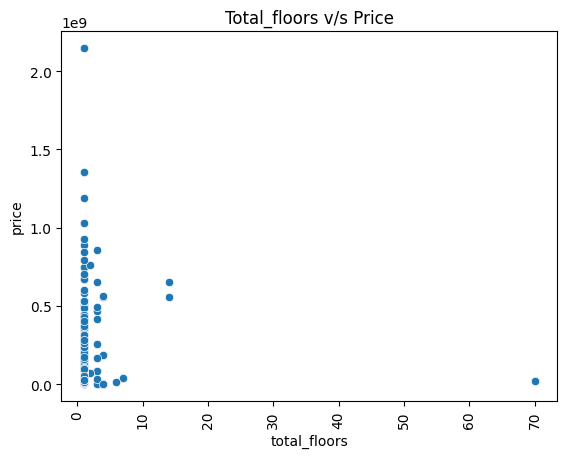

In [88]:
sns.scatterplot(x=data['total_floors'],y=data['price'])
plt.xticks(rotation=90)
plt.title('Total_floors v/s Price')

# Identifying Outliers

<Axes: ylabel='area'>

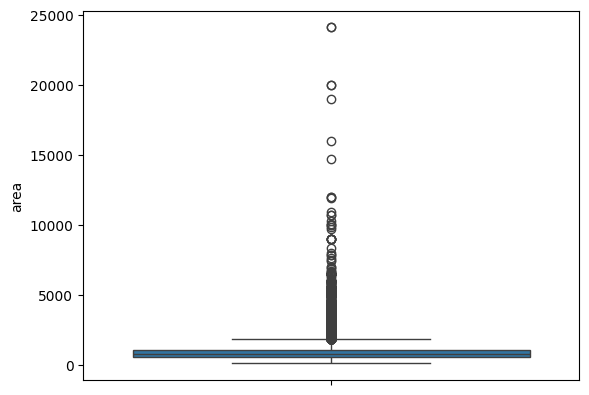

In [89]:
sns.boxplot(data['area'])

<Axes: ylabel='price_per_sqft'>

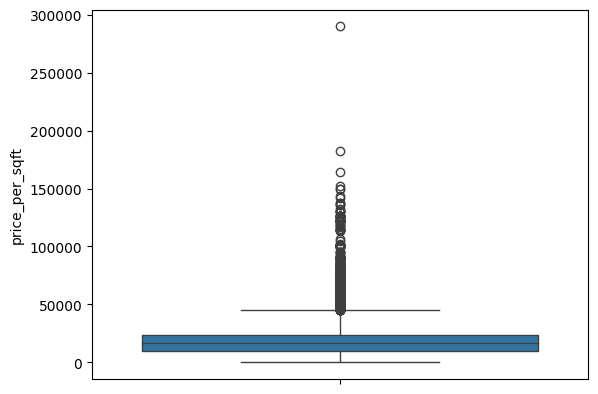

In [90]:
sns.boxplot(data['price_per_sqft'])

<Axes: ylabel='bedroom_num'>

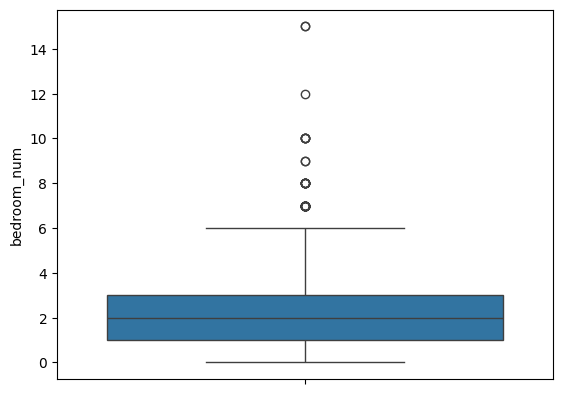

In [91]:
sns.boxplot(data['bedroom_num'])

<Axes: ylabel='bathroom_num'>

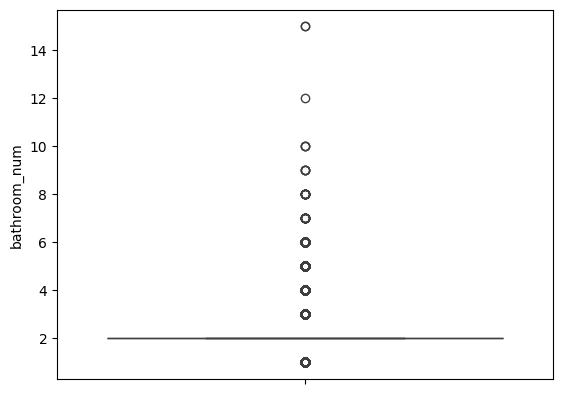

In [92]:
sns.boxplot(data['bathroom_num'])

<Axes: ylabel='balcony_num'>

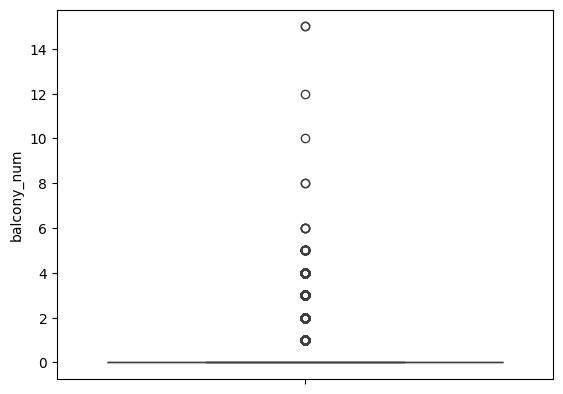

In [93]:
sns.boxplot(data['balcony_num'])

<Axes: ylabel='age'>

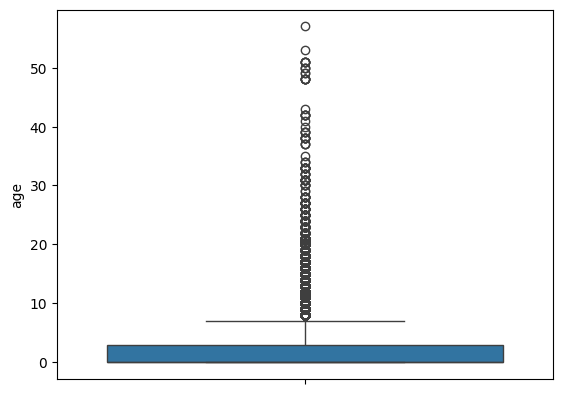

In [94]:
sns.boxplot(data['age'])

<Axes: ylabel='total_floors'>

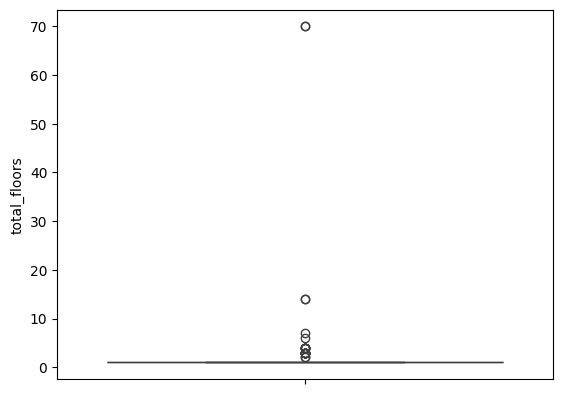

In [95]:
sns.boxplot(data['total_floors'])

# Removing Outliers

In [96]:
num_cols=['area','price_per_sqft','bedroom_num','bathroom_num','balcony_num','age','total_floors']

In [97]:
cat_cols=['title','locality','property_type','city','furnished']

In [98]:
data_cap = data.copy()

for i in num_cols:
  Q3 = data[i].quantile(0.75)
  Q1 = data[i].quantile(0.25)
  IQR=Q3-Q1

  upper_limit = Q3 + 1.5*IQR
  lower_limit = Q1 - 1.5*IQR

  data_cap[i]=np.where(data_cap[i]>upper_limit,
                       upper_limit,
                       np.where(data_cap[i]<lower_limit,
                       lower_limit,data_cap[i]))

data = data_cap.copy()

/tmp/ipykernel_2397/2395652314.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[name], color='red', label="Original")
/tmp/ipykernel_2397/2395652314.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data_cap[name], color='black', label="Capped")
/tmp/ipykernel_2397/2395652314.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_2397/2395652314.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[name], color='red', label="Original")
/tmp/ipykernel_2397/2395652314.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this 

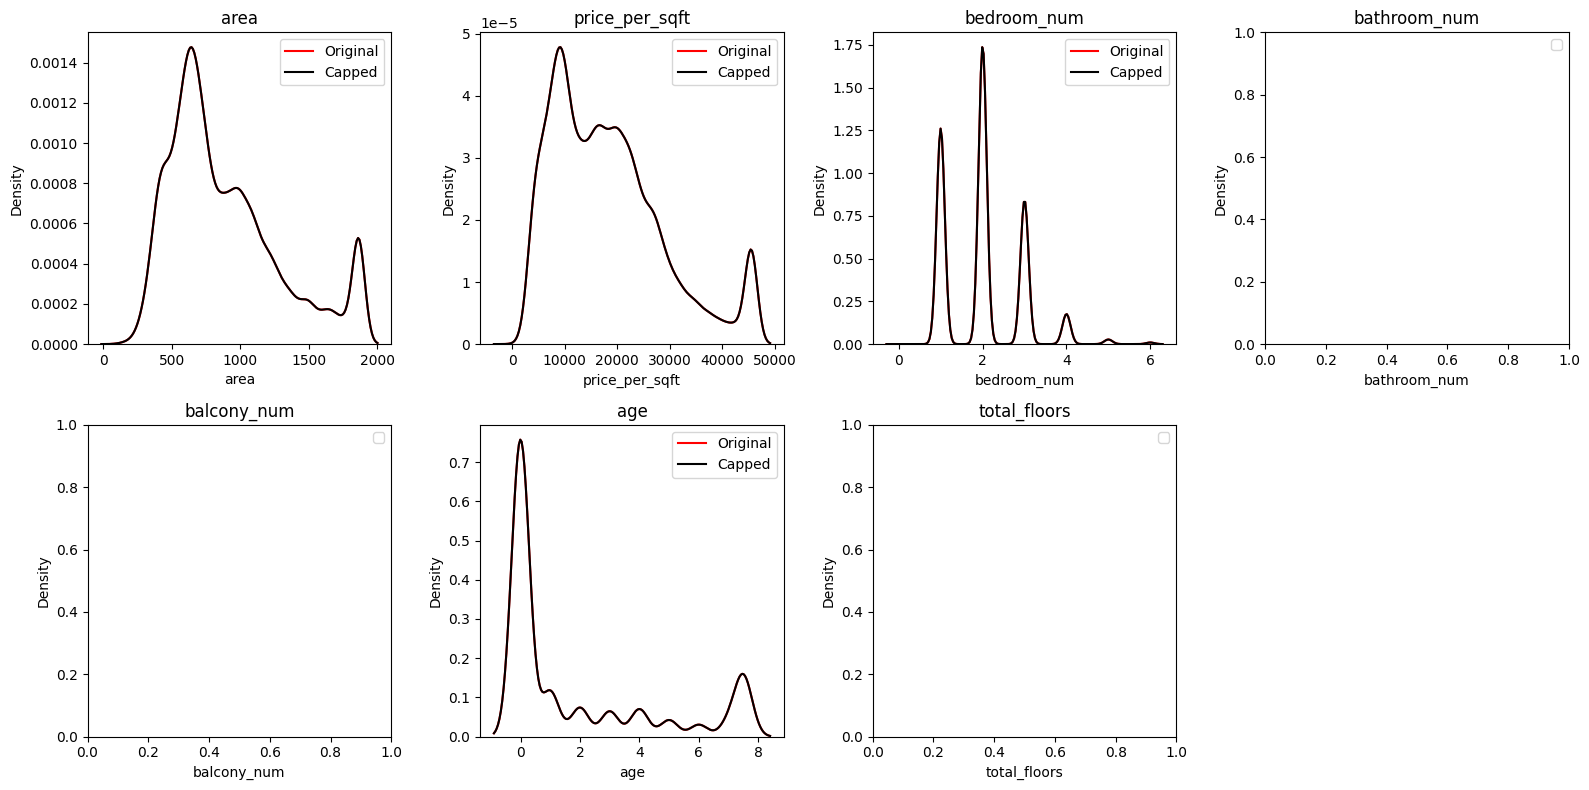

In [99]:
plt.figure(figsize=(16,8))

for col_no, name in enumerate(num_cols, 1):
    plt.subplot(2,4,col_no)
    sns.kdeplot(data[name], color='red', label="Original")
    sns.kdeplot(data_cap[name], color='black', label="Capped")
    plt.title(name)
    plt.legend()

plt.tight_layout()
plt.show()


# Dealt with skewness

In [100]:
for i in num_cols:
  data[i]=np.log1p(data[i])
  print(f"Skewness of {i} : ",data[i].skew())

Skewness of area :  0.028289859954727825
Skewness of price_per_sqft :  -0.38743770915217896
Skewness of bedroom_num :  0.12452296391877059
Skewness of bathroom_num :  0.0
Skewness of balcony_num :  0.0
Skewness of age :  0.7189291625472061
Skewness of total_floors :  0.0


# Training the model

In [101]:
x=data.drop(columns='price')
y=data['price']

In [102]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=2,test_size=0.2)

In [103]:
trf=ColumnTransformer(transformers=(
    ('standardise',StandardScaler(),num_cols),
    ('Ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['city','property_type']),
    ('ordinal',OrdinalEncoder(categories=[['Unfurnished','Semi-Furnished','Furnished']]),['furnished']),
    ('targetsEncoder',TargetEncoder(),['title','locality'])

))

In [104]:
pipe=Pipeline(
    [('pipe1',trf),
    ('pipe2',XGBRegressor())]
)

# Accuarcy metrics

In [105]:
pipe.fit(x_train,y_train)
y_pred=pipe.predict(x_test)

In [106]:
r2_score(y_pred,y_test)

0.8867630362510681

# Checking for overfitting

In [107]:
y_train_pred = pipe.predict(x_train)

print(f'R2 score for training data: {r2_score(y_train, y_train_pred):.4f}')
print(f'R2 score for test data: {r2_score(y_test, y_pred):.4f}')

R2 score for training data: 0.9138
R2 score for test data: 0.9127


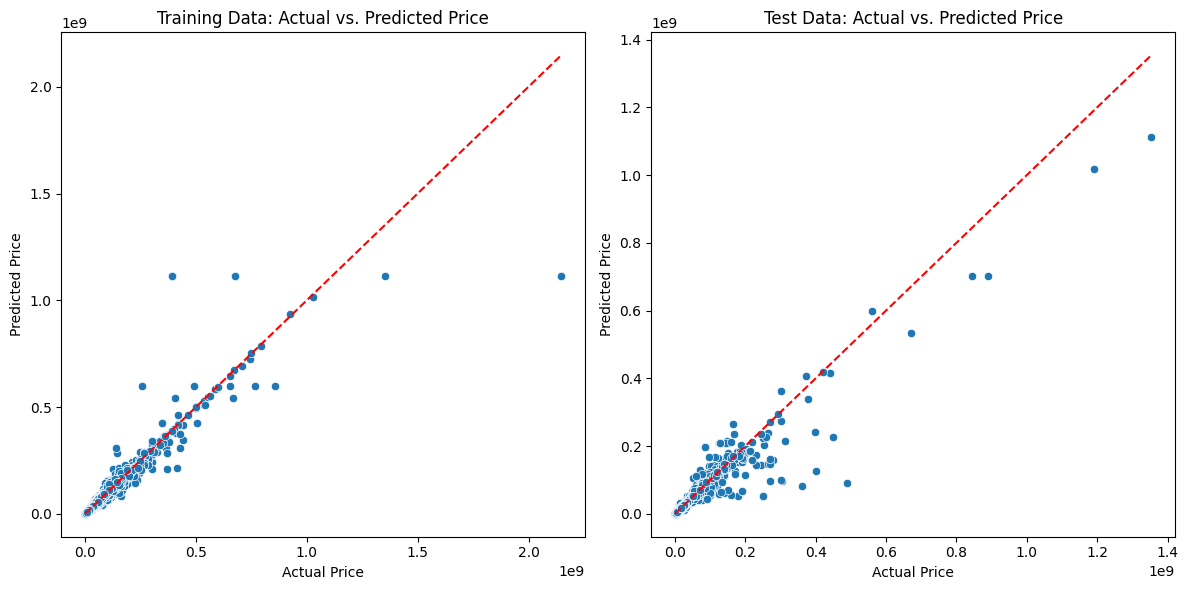

In [108]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train, y=y_train_pred)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.title('Training Data: Actual vs. Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Test Data: Actual vs. Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.tight_layout()
plt.show()